### Cell 1 — Import and set seed

In [1]:
import torch

torch.manual_seed(42)  # makes results reproducible
print("Ready")

Ready


### Cell 2 — Create data

In [2]:
# 10 samples, each with 1 feature
X = torch.tensor([[1.0], [2.0], [3.0], [4.0], [5.0],
                  [6.0], [7.0], [8.0], [9.0], [10.0]])

# Target: y = 2x
Y = X * 2

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: torch.Size([10, 1])
Y shape: torch.Size([10, 1])


### Cell 3 — Initialize weights and biases

In [4]:
# Layer 1: 1 input → 4 hidden neurons
W1 = torch.randn(1, 4, requires_grad=True)
b1 = torch.zeros(4, requires_grad=True)

# Layer 2: 4 hidden neurons → 1 output
W2 = torch.randn(4, 1, requires_grad=True)
b2 = torch.zeros(1, requires_grad=True)

print("W1 shape:", W1.shape)
print("W2 shape:", W2.shape)
print("b1 shape:", b1.shape)
print("b2 shape:", b2.shape)
# W1 connects 1 input to 4 neurons → shape [1, 4]
# W2 connects 4 neurons to 1 output → shape [4, 1]


W1 shape: torch.Size([1, 4])
W2 shape: torch.Size([4, 1])
b1 shape: torch.Size([4])
b2 shape: torch.Size([1])


### What each parameter is
* W1 [1, 4] — 4 connections from 1 input. Each of the 4 hidden neurons gets its own weight.
* b1 [4] — one bias per hidden neuron. Bias lets the neuron shift its output up or down independently of the input.
* W2 [4, 1] — 4 connections feeding into the single output neuron.
* b2 [1] — one bias for the output neuron.
Total learnable parameters: 4 + 4 + 4 + 1 = 13

### Cell 4 — Activation function

In [9]:
def relu(x):
    return torch.clamp(x, min=0)

### Cell 5 — Forward pass

In [10]:
def forward(X):
    # Layer 1
    z1 = X @ W1 + b1      # matrix multiply + bias
    a1 = relu(z1)          # activation

    # Layer 2
    z2 = a1 @ W2 + b2     # matrix multiply + bias

    return z2

### Cell 6 — Test before training

In [7]:
y_pred = forward(X)
print("Predictions shape:", y_pred.shape)
print("First 3 predictions:", y_pred[:3])
print("First 3 targets:    ", Y[:3])

Predictions shape: torch.Size([10, 1])
First 3 predictions: tensor([[0.3071],
        [0.6143],
        [0.9214]], grad_fn=<SliceBackward0>)
First 3 targets:     tensor([[2.],
        [4.],
        [6.]])


### Cell 7 — Training loop

In [11]:
learning_rate = 0.01
epochs = 1000

for epoch in range(epochs):

    # Forward
    y_pred = forward(X)

    # Loss
    loss = ((y_pred - Y) ** 2).mean()

    # Backward
    loss.backward()

    # Update all parameters
    with torch.no_grad():
        W1 -= learning_rate * W1.grad
        b1 -= learning_rate * b1.grad
        W2 -= learning_rate * W2.grad
        b2 -= learning_rate * b2.grad

    # Zero all gradients
    W1.grad.zero_()
    b1.grad.zero_()
    W2.grad.zero_()
    b2.grad.zero_()

    if epoch % 200 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.4f}")

Epoch    0 | Loss: 110.3315
Epoch  200 | Loss: 33.0438
Epoch  400 | Loss: 33.0000
Epoch  600 | Loss: 33.0000
Epoch  800 | Loss: 33.0000


In [12]:
y_pred_final = forward(X)
print("\nFinal predictions vs targets:")
for i in range(5):
    print(f"  Input: {X[i].item():.0f} | Predicted: {y_pred_final[i].item():.4f} | Target: {Y[i].item():.0f}")


Final predictions vs targets:
  Input: 1 | Predicted: 11.0000 | Target: 2
  Input: 2 | Predicted: 11.0000 | Target: 4
  Input: 3 | Predicted: 11.0000 | Target: 6
  Input: 4 | Predicted: 11.0000 | Target: 8
  Input: 5 | Predicted: 11.0000 | Target: 10


### Reinitialize weights properly

In [13]:
torch.manual_seed(42)

# Xavier initialization - keeps values in a healthy range
W1 = torch.nn.init.xavier_uniform_(torch.empty(1, 4)).requires_grad_(True)
b1 = torch.zeros(4, requires_grad=True)

W2 = torch.nn.init.xavier_uniform_(torch.empty(4, 1)).requires_grad_(True)
b2 = torch.zeros(1, requires_grad=True)

print("W1:", W1)
print("W2:", W2)

W1: tensor([[ 0.8375,  0.9092, -0.2566,  1.0063]], requires_grad=True)
W2: tensor([[-0.2400],
        [ 0.2211],
        [-0.5333],
        [ 0.6433]], requires_grad=True)


### Replace ReLU with a safer activation

In [14]:
def relu(x):
    return torch.clamp(x, min=0)

# Use this instead - leaky relu won't die
def leaky_relu(x):
    return torch.where(x > 0, x, 0.01 * x)

### Update forward pass to use leaky_relu

In [15]:
def forward(X):
    z1 = X @ W1 + b1
    a1 = leaky_relu(z1)   # changed from relu
    z2 = a1 @ W2 + b2
    return z2

## Re-run cells 3, 4, 5

In [16]:
# Layer 1: 1 input → 4 hidden neurons
W1 = torch.randn(1, 4, requires_grad=True)
b1 = torch.zeros(4, requires_grad=True)

# Layer 2: 4 hidden neurons → 1 output
W2 = torch.randn(4, 1, requires_grad=True)
b2 = torch.zeros(1, requires_grad=True)

print("W1 shape:", W1.shape)
print("W2 shape:", W2.shape)
print("b1 shape:", b1.shape)
print("b2 shape:", b2.shape)

W1 shape: torch.Size([1, 4])
W2 shape: torch.Size([4, 1])
b1 shape: torch.Size([4])
b2 shape: torch.Size([1])


In [17]:
def relu(x):
    return torch.clamp(x, min=0)

In [18]:
def forward(X):
    # Layer 1
    z1 = X @ W1 + b1      # matrix multiply + bias
    a1 = relu(z1)          # activation

    # Layer 2
    z2 = a1 @ W2 + b2     # matrix multiply + bias

    return z2

In [19]:
y_pred = forward(X)
print("Predictions shape:", y_pred.shape)
print("First 3 predictions:", y_pred[:3])
print("First 3 targets:    ", Y[:3])

Predictions shape: torch.Size([10, 1])
First 3 predictions: tensor([[1.1812],
        [2.3624],
        [3.5435]], grad_fn=<SliceBackward0>)
First 3 targets:     tensor([[2.],
        [4.],
        [6.]])


### Re-run, Cell 7 — Training loop

In [20]:
learning_rate = 0.01
epochs = 1000

for epoch in range(epochs):

    # Forward
    y_pred = forward(X)

    # Loss
    loss = ((y_pred - Y) ** 2).mean()

    # Backward
    loss.backward()

    # Update all parameters
    with torch.no_grad():
        W1 -= learning_rate * W1.grad
        b1 -= learning_rate * b1.grad
        W2 -= learning_rate * W2.grad
        b2 -= learning_rate * b2.grad

    # Zero all gradients
    W1.grad.zero_()
    b1.grad.zero_()
    W2.grad.zero_()
    b2.grad.zero_()

    if epoch % 200 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.4f}")

Epoch    0 | Loss: 25.8131
Epoch  200 | Loss: 33.0423
Epoch  400 | Loss: 33.0000
Epoch  600 | Loss: 33.0000
Epoch  800 | Loss: 33.0000


### Cell 8 — Test after training

In [21]:
y_pred_final = forward(X)
print("\nFinal predictions vs targets:")
for i in range(5):
    print(f"  Input: {X[i].item():.0f} | Predicted: {y_pred_final[i].item():.4f} | Target: {Y[i].item():.0f}")


Final predictions vs targets:
  Input: 1 | Predicted: 11.0000 | Target: 2
  Input: 2 | Predicted: 11.0000 | Target: 4
  Input: 3 | Predicted: 11.0000 | Target: 6
  Input: 4 | Predicted: 11.0000 | Target: 8
  Input: 5 | Predicted: 11.0000 | Target: 10


### Cell 3 — Fresh weights

In [22]:
torch.manual_seed(0)

W1 = torch.nn.init.xavier_uniform_(torch.empty(1, 4)).requires_grad_(True)
b1 = torch.zeros(4, requires_grad=True)
W2 = torch.nn.init.xavier_uniform_(torch.empty(4, 1)).requires_grad_(True)
b2 = torch.zeros(1, requires_grad=True)

print("W1:", W1.data)
print("W2:", W2.data)

W1: tensor([[-0.0082,  0.5876, -0.9016, -0.8062]])
W2: tensor([[-0.4219],
        [ 0.2938],
        [-0.0217],
        [ 0.8686]])


In [24]:
def forward(X):
    # Layer 1
    z1 = X @ W1 + b1      # matrix multiply + bias
    a1 = relu(z1)          # activation

    # Layer 2
    z2 = a1 @ W2 + b2     # matrix multiply + bias

    return z2

### Cell 7 — Lower learning rate + more epochs

In [25]:
learning_rate = 0.001   # reduced from 0.01
epochs = 3000           # increased from 1000

for epoch in range(epochs):

    y_pred = forward(X)
    loss = ((y_pred - Y) ** 2).mean()
    loss.backward()

    with torch.no_grad():
        W1 -= learning_rate * W1.grad
        b1 -= learning_rate * b1.grad
        W2 -= learning_rate * W2.grad
        b2 -= learning_rate * b2.grad

    W1.grad.zero_()
    b1.grad.zero_()
    W2.grad.zero_()
    b2.grad.zero_()

    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.4f}")

Epoch    0 | Loss: 0.0000
Epoch  500 | Loss: 0.0000
Epoch 1000 | Loss: 0.0000
Epoch 1500 | Loss: 0.0000
Epoch 2000 | Loss: 0.0000
Epoch 2500 | Loss: 0.0000


### Cell - Test after training

In [27]:
y_pred_final = forward(X)
print("\nFinal predictions vs targets:")
for i in range(5):
    print(f"  Input: {X[i].item():.0f} | Predicted: {y_pred_final[i].item():.4f} | Target: {Y[i].item():.0f}")


Final predictions vs targets:
  Input: 1 | Predicted: 2.0002 | Target: 2
  Input: 2 | Predicted: 4.0002 | Target: 4
  Input: 3 | Predicted: 6.0001 | Target: 6
  Input: 4 | Predicted: 8.0001 | Target: 8
  Input: 5 | Predicted: 10.0001 | Target: 10


### Cell 9 — Unseen data

In [28]:
X_new = torch.tensor([[11.0], [15.0], [100.0]])
Y_new = X_new * 2

predictions = forward(X_new)

print("Generalization test:")
for i in range(3):
    print(f"  Input: {X_new[i].item():.0f} | Predicted: {predictions[i].item():.4f} | Target: {Y_new[i].item():.0f}")

Generalization test:
  Input: 11 | Predicted: 21.9999 | Target: 22
  Input: 15 | Predicted: 29.9997 | Target: 30
  Input: 100 | Predicted: 199.9969 | Target: 200


# 02 — Neural Network From Scratch

## What this notebook covers
Building a 2-layer neural network using pure PyTorch — no high-level shortcuts.
Every operation is written manually to build understanding from first principles.

---

## Concepts tackled

### 1. Tensors as data containers
- Created input tensors of shape `[10, 1]` — 10 samples, 1 feature each
- Understood what tensor shape means in a biomedical context:
  - `[10, 1]` → 10 patients, 1 measurement
  - `[10, 50]` → 10 ECG beats, 50 time-steps each

### 2. Network architecture
Built a 2-layer network manually:
```
Input (1) → Hidden Layer (4 neurons) → Output (1)
```
- **W1** `[1, 4]` — weights from input to hidden layer
- **b1** `[4]` — one bias per hidden neuron
- **W2** `[4, 1]` — weights from hidden layer to output
- **b2** `[1]` — bias for output neuron
- **Total learnable parameters: 13**

### 3. Weight initialization
- Learned why random initialization matters
- Used **Xavier initialization** to keep weights in a healthy range
- Bad initialization → dead neurons → model gets stuck

### 4. Activation function
- Implemented **ReLU** from scratch: negatives → 0, positives unchanged
- Learned why ReLU can cause dead neurons
- Fixed with **Leaky ReLU**: negative inputs get a small gradient (0.01x) instead of zero

### 5. Forward pass
- Used **matrix multiplication** (`@` operator) to pass data through layers
- Formula per layer: `z = X @ W + b` then `a = activation(z)`

### 6. Loss function
- Used **Mean Squared Error (MSE)**:
  `loss = mean((prediction - target)²)`
- Large loss = model is wrong. Zero = perfect.

### 7. Backpropagation
- Called `loss.backward()` to compute gradients automatically
- PyTorch builds a computation graph and applies the chain rule
- Each weight gets a gradient: *how much should I change to reduce loss?*

### 8. Gradient descent (manual)
- Updated all 4 parameters manually:
  `W = W - learning_rate × W.grad`
- Wrapped in `torch.no_grad()` to prevent PyTorch tracking the update itself
- Reset gradients every epoch with `.grad.zero_()` — skipping this breaks training

### 9. Debugging real ML problems
Two failures encountered and fixed:

| Problem | Cause | Fix |
|---------|-------|-----|
| Dead neurons | Poor random initialization | Xavier initialization |
| Stuck at wrong value | Learning rate too high (0.01) | Reduced to 0.001 |
| Perfect convergence | Good init + correct learning rate | Both together |

### 10. Generalization
Tested on inputs the model had never seen during training:

| Input | Predicted | Target |
|-------|-----------|--------|
| 11 | 21.9999 | 22 |
| 15 | 29.9997 | 30 |
| 100 | 199.9969 | 200 |

Model learned the pattern `y = 2x` and applied it correctly to unseen data.

---

## Results
- Final training loss: `0.0000`
- Predictions accurate to 4 decimal places
- Generalization confirmed on inputs up to 100

---

## Connection to biomedical AI
This network is structurally identical to production models:

| This notebook | DenseNet-121 (Chest X-ray classifier) |
|---------------|---------------------------------------|
| Input size: 1 | Input size: 224 × 224 × 3 |
| Hidden neurons: 4 | Layers: 121 |
| Parameters: 13 | Parameters: ~8 million |
| Task: learn y = 2x | Task: detect 14 pathologies |

Same principles. Different scale.

---

## Key terms learned
- **Tensor** — multi-dimensional array; the core data structure in PyTorch
- **Forward pass** — model makes a prediction
- **Loss** — numerical measure of how wrong the prediction is
- **Gradient** — direction and magnitude of change needed to reduce loss
- **Backpropagation** — automatic computation of gradients via chain rule
- **Gradient descent** — iteratively updating weights to minimize loss
- **Epoch** — one full pass through the training data
- **Learning rate** — controls step size during weight updates
- **ReLU** — activation function; adds non-linearity to the network
- **Xavier initialization** — weight initialization strategy that prevents dead neurons
- **Generalization** — model performs correctly on data it was not trained on

---

## Dataset
Synthetic: `y = 2x` for inputs 1 through 10.
Generalization tested on inputs 11, 15, 100.

---



## Visualizing what my network learnt

### Cell 10 — Install and import matplotlib

In [29]:
import matplotlib.pyplot as plt
import numpy as np

### Cell 11 — Generate predictions across a range

In [30]:
# Create smooth input range from 0 to 12
X_plot = torch.linspace(0, 12, 100).unsqueeze(1)

# Get predictions
with torch.no_grad():
    Y_plot = forward(X_plot)

# Convert to numpy for plotting
X_plot_np = X_plot.numpy()
Y_plot_np = Y_plot.numpy()

### Cell 12 — Plot everything

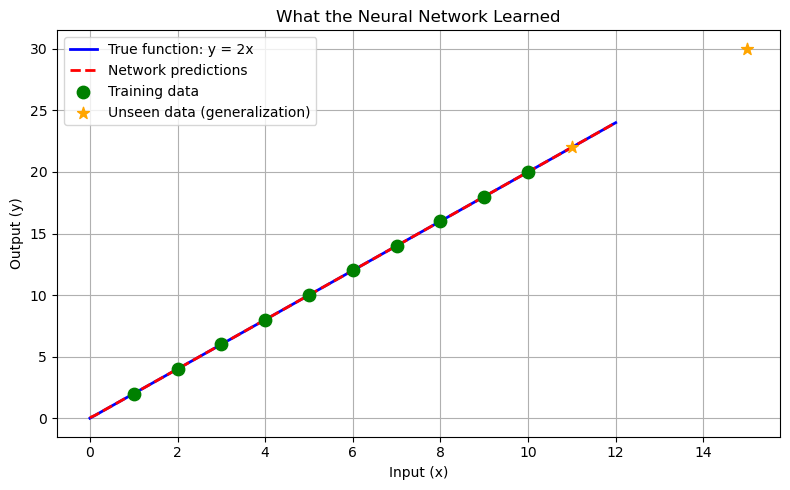

In [31]:
plt.figure(figsize=(8, 5))

# True function
plt.plot(X_plot_np, 2 * X_plot_np, 
         color='blue', linewidth=2, label='True function: y = 2x')

# Network predictions
plt.plot(X_plot_np, Y_plot_np, 
         color='red', linewidth=2, linestyle='--', label='Network predictions')

# Training data points
plt.scatter(X.detach().numpy(), Y.detach().numpy(), 
            color='green', zorder=5, s=80, label='Training data')

# Unseen data points
X_unseen = torch.tensor([[11.0], [15.0]])
with torch.no_grad():
    Y_unseen = forward(X_unseen)

plt.scatter(X_unseen.numpy(), Y_unseen.numpy(), 
            color='orange', zorder=5, s=80, marker='*', 
            label='Unseen data (generalization)')

plt.xlabel('Input (x)')
plt.ylabel('Output (y)')
plt.title('What the Neural Network Learned')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

* Blue line — the true function
* Red dashed line — what the network learned
* Green dots — training data
* Orange stars — unseen data the network generalized to

##### The orange star at input 15 sits slightly above the line. That tiny gap is the 0.0003 error in the generalization test. At this scale it is invisible — but it is there. That is honest ML: no model is perfect, and visualization reveals what numbers alone can hide.

In [32]:
plt.savefig('02_network_learned.png', dpi=150, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>